In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
X_train = pd.read_csv('../data/interim/X_train.csv')
y_train = pd.read_csv('../data/interim/y_train.csv')

# Exploratory Data Analysis

## 1. Feature Distributions

### 1.1 Numeric Features

It includes Age, Fare, SibSp and Parch.

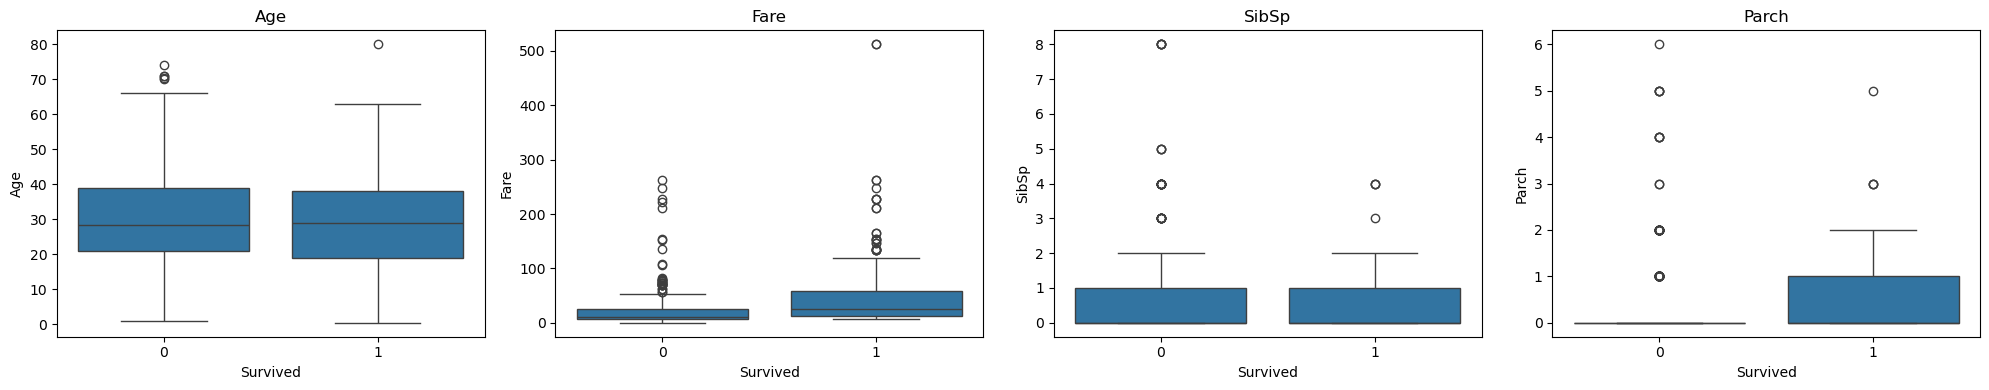

In [3]:
train = X_train.copy()
train['Survived'] = y_train

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Survived', y=col, data=train, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [4]:
train[train['Fare'] > 400]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
259,738,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,1
708,259,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,1


The first code above compares side by side the two classes *Survived* and *Died* through a boxplot in order to identify any outliers or how informative is each feature, and the second code checks who are these passengers that payed more than 400. These are the following observations:

- *Age* and *SibSp* have identical boxplots in both classes meaning that these alone are not a significant indicator of whether the passenger will survive or not.
- *Fare*, there is a difference between the two classes meaning perhaphs this feature can help decide the value of the target variable because people that payed more well more than 40 have a better chance to survive.
- *Parch* is a bit different, people who travelled with a parent/child have a better chance to survive this may be related to women and children first.
- The outliers on Fare (e.g. 512.33) were investigated: two passengers share the same Ticket number (PC 17755) and identical Fare value. This strongly suggests Fare sometimes represents a total price for a group booking, duplicated across everyone on that ticket, rather than a true per-person price. This makes Fare a slightly noisier proxy for individual wealth than it first appears — worth revisiting later as a possible `Fare_per_person` feature (Fare divided by group size).
- The remaining outliers (Age, SibSp, Parch) appear to be genuine, plausible values (large families, elderly passengers) rather than data errors.

### 1.2 Categorical Features

It includes Sex, Embarked and Pclass.

In [5]:
categorical_cols = ['Sex', 'Embarked', 'Pclass']

for col in categorical_cols:
    print(train.groupby(col)['Survived'].mean())
    print()

Sex
female    0.743083
male      0.185185
Name: Survived, dtype: float64

Embarked
C    0.561151
Q    0.436364
S    0.327519
Name: Survived, dtype: float64

Pclass
1    0.649123
2    0.446667
3    0.242967
Name: Survived, dtype: float64



The code above calculates the mean of survivals for each class for each feature. These are the following observations:
- *Sex*: females are more likely to survive.
- *Pclass*: class 1 is more likely to survive followed by class 2.
- *Embarked*: Embarked: Cherbourg passengers show a higher survival rate, but this is likely because Cherbourg had a higher proportion of first-class passengers — Embarked acts as a proxy for Pclass rather than a direct cause of survival.

## 2. The relation between Pclass and Embarked

Here we will check if there is a relationship between Pclass and Embarked to confirm what we said earlier.

In [11]:
X_train.groupby('Embarked')['Pclass'].value_counts(normalize=True)

Embarked  Pclass
C         1         0.532374
          3         0.381295
          2         0.086331
Q         3         0.945455
          2         0.036364
          1         0.018182
S         3         0.554264
          2         0.263566
          1         0.182171
Name: proportion, dtype: float64

**Relation between Pclass and Embarked (on X_train)**

- Cherbourg (C): 53.2% class 1, 38.1% class 3, 8.6% class 2 — skews heavily toward first class.
- Queenstown (Q): 94.5% class 3, 3.6% class 2, 1.8% class 1 — almost entirely third class.
- Southampton (S): 55.4% class 3, 26.4% class 2, 18.2% class 1 — mostly third class, but more mixed than Q.

This confirms the pattern found earlier: Cherbourg's high survival rate isn't caused by the port itself, but by the fact that Cherbourg passengers were disproportionately  first-class.

## 3. The relation between Pclass and Cabin

Here we will check if there is a relationship between Pclass and Cabin the hypothesis i had is if it is a third class there is no Cabin value 

In [9]:
X_train.groupby('Pclass')['Cabin'].apply(lambda x: x.isnull().mean())

Pclass
1    0.204678
2    0.900000
3    0.976982
Name: Cabin, dtype: float64

The code above groups by Pclass and calculates the mean of null passengers that do not have Cabin. These are the following observations:

- Class 1: 20.5% missing
- Class 2: 90.0% missing
- Class 3: 97.7% missing
- class 1 mostly has Cabin recorded, and classes 2 and 3 are both overwhelmingly missing, at nearly the same rate.

**Decision: Drop `Cabin`**
1. ~90-98% missing depending on class — too sparse to impute reliably; filling this much 
   of a column would mean fabricating data, not estimating it.
2. What little signal Cabin carries (presence vs. absence) is redundant with Pclass — 
   missingness itself splits almost cleanly along class lines (class 1: ~20% missing, 
   class 2/3: ~90-98% missing). A Has_Cabin feature would add little beyond what 
   Pclass already provides.

## 4. Correlations (feature vs. target, and feature vs. feature / multicollinearity)

Survived    1.000000
Fare        0.275499
Parch       0.084178
SibSp      -0.026115
Age        -0.084268
Pclass     -0.348007
Name: Survived, dtype: float64


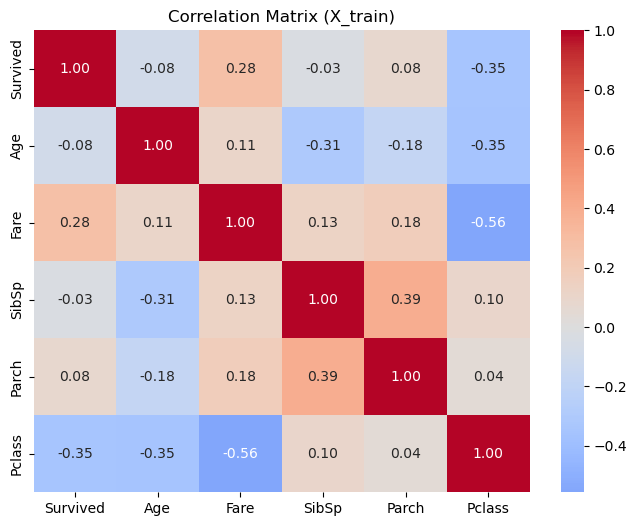

In [6]:
# recombine so Survived is included in the correlation check
train = X_train.copy()
train['Survived'] = y_train

# select only numeric columns for correlation
numeric_cols = ['Survived', 'Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

corr_matrix = train[numeric_cols].corr()
print(corr_matrix['Survived'].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix (X_train)')
plt.show()

The code above plots the correlation matrix between features and between each feature and the target variable. The results show:

1. **Between each feature and the target variable**
    - The strongest correlation is the one between the target variable and **Pclass** (-0.35) means when the class is higher (meaning less class) the chance to survive decreases.
    - The second strongest correlation is between the target variable and **Fare** (0.28) means when the person pays more (a passenger with first class) the chance to survive increases.
    - The other correlations are almost 0 meaning there is no relationship between these features (age, sibsp and parch) and the target variable.

2. **Between features**
    - There is a moderate negative correlation between **Age** and **SibSp** (-0.31) which probably returns to the fact that younger people like children travel usually with their family members and siblings.
    - There is a moderate negative correlation between **Age** and **Pclass** (-0.35) which means that older/wealthier passengers tended to choose or afford first-class tickets, while children were more often traveling in cheaper (third-class) family bookings.
    - There is a weak negative correlation between **Age** and **Parch** (-0.18) and a weak positive one between **Age** and **Fare** (0.11).
    - There are two weak positive correlations, one between **Fare** and **SibSp** (0.11) and the second between **Fare** and **Parch** (0.18).
    - There is a sifnificant negative correlation between **Fare** and **Pclass** (-0.56) which confirms there is a moderate **multicollinearity** which means that both these features give the same information.
    - There is a moderate correlation between **SibSp** and **Parch** (0.39) which means that almost the passengers travel with their family members (parents and siblings).
    - There are two weak positive correlations one between **SibSp** and **Pclass** and the second between **Parch** and **Pclass**.

This multicollinearity is not severe i will decide later weather to drop or keep both features based on the models i use.

## 5. Target Leakage Verification

The train/val leakage is excluded because we are already exploring data only on the train set.However, there may be still a target leakage, which is a type of leakage where it exists a feature or features that helps predict the target value.

All the features in this dataset are recorded before the disaster (at a booking time) so there is no target leakage.

## 6. Categorical Cardinality

In [4]:
for col in ['Sex', 'Embarked', 'Pclass', 'Ticket', 'Name']:
    print(col, X_train[col].nunique())

Sex 2
Embarked 3
Pclass 3
Ticket 571
Name 712


In [5]:
X_train['Name'].head(10)

0                                         Lam, Mr. Ali
1                     Frost, Mr. Anthony Wood "Archie"
2                                   Farthing, Mr. John
3                           Aks, Mrs. Sam (Leah Rosen)
4          Collyer, Mrs. Harvey (Charlotte Annie Tate)
5                       Kalvik, Mr. Johannes Halvorsen
6                                       Lang, Mr. Fang
7                                  Robbins, Mr. Victor
8                         McCormack, Mr. Thomas Joseph
9    Vander Planke, Mrs. Julius (Emelia Maria Vande...
Name: Name, dtype: object

The code above counts the unique values for the categorical features. These are the following results:

**Observations:**
- **Sex**, **Embarked** and **Pclass** have a reasonable cardinality.
- There are 571 different values for the **Ticket** which confirms the theory that there may be shared tickets maybe for a family.
- **Name** recorded 712 unique values which is same the total of rows for this training set.

**Decisions:**
- **Name** feature carries social information about the person for example *Miss*, *Mr* and so on, which may give the priority to women first. Checking ten rows for the Name we notice a pattern *Lastname, Title. Firstname* which allows us to extract only this small information rather than keeping the whole name.
- Drop raw `Ticket`, engineer `Group_Size` and `Fare_per_person`
- Group_Size = count of passengers sharing the same Ticket number.
- Fare_per_person = Fare / Group_Size (fixes the group-total Fare issue found earlier).
- Not redundant with SibSp/Parch: e.g. Lesurer & Ward share a ticket (Group_Size=2) but both have SibSp=0, Parch=0 — proving ticket-sharing captures companionship beyond official family relationships.